In [2]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 11.7 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,precision_score, recall_score, f1_score,roc_auc_score,confusion_matrix,roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Pranaya\creditworthiness\archive (1)\bankloans.csv')
df

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0
...,...,...,...,...,...,...,...,...,...
845,34,1,12,15,32,2.7,0.239328,0.624672,NaN
846,32,2,12,11,116,5.7,4.026708,2.585292,NaN
847,48,1,13,11,38,10.8,0.722304,3.381696,NaN
848,35,2,1,11,24,7.8,0.417456,1.454544,NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


# delete all NaN rows to get proper accuracy

In [4]:
df = df.dropna(subset=['default'])
df

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0
...,...,...,...,...,...,...,...,...,...
695,36,2,6,15,27,4.6,0.262062,0.979938,1.0
696,29,2,6,4,21,11.5,0.369495,2.045505,0.0
697,33,1,15,3,32,7.6,0.491264,1.940736,0.0
698,45,1,19,22,77,8.4,2.302608,4.165392,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       700 non-null    int64  
 1   ed        700 non-null    int64  
 2   employ    700 non-null    int64  
 3   address   700 non-null    int64  
 4   income    700 non-null    int64  
 5   debtinc   700 non-null    float64
 6   creddebt  700 non-null    float64
 7   othdebt   700 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


In [5]:
# change the data type of dependent variable to int 
df['default'] =df['default'].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       700 non-null    int64  
 1   ed        700 non-null    int64  
 2   employ    700 non-null    int64  
 3   address   700 non-null    int64  
 4   income    700 non-null    int64  
 5   debtinc   700 non-null    float64
 6   creddebt  700 non-null    float64
 7   othdebt   700 non-null    float64
 8   default   700 non-null    int32  
dtypes: float64(3), int32(1), int64(5)
memory usage: 52.0 KB


C:\Users\owner\AppData\Local\Temp\ipykernel_9544\555069926.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['default'] =df['default'].astype(int)


#EDA

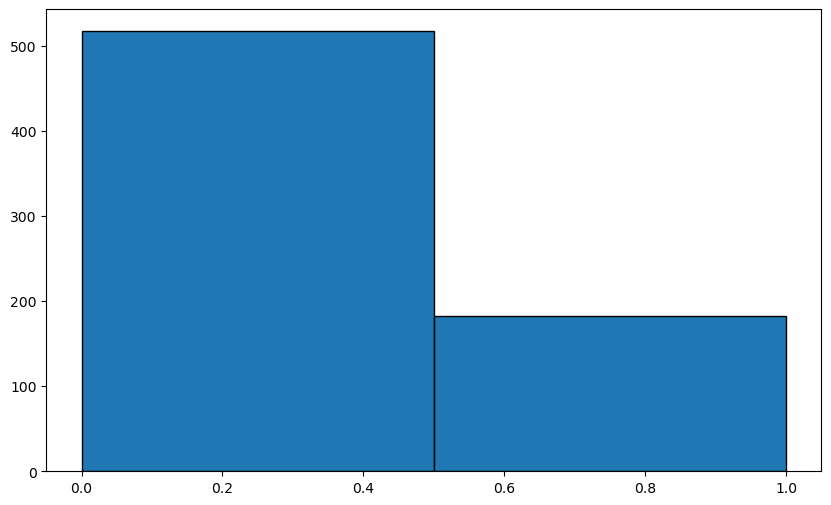

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df['default'], bins=2, edgecolor='black')
plt.show()

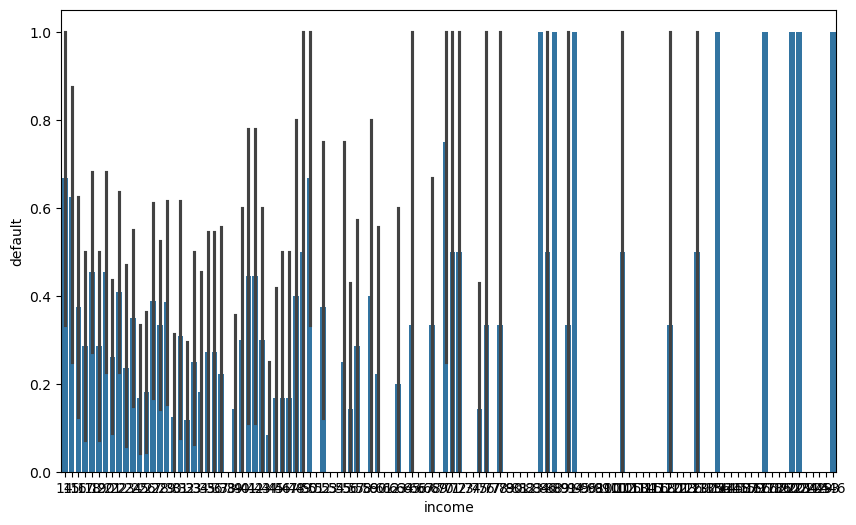

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x = df['income'],y = df['default'])
plt.show()

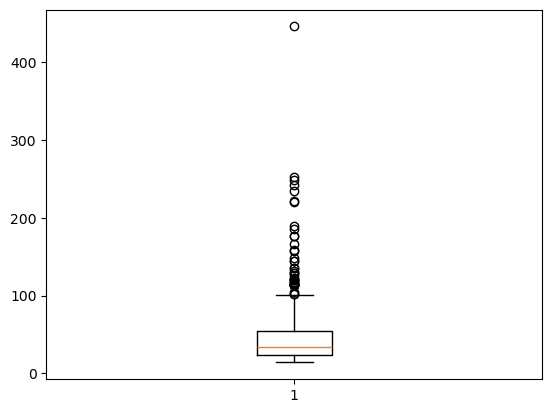

In [7]:
plt.boxplot(df['income'])
plt.show()
# dataset is having outliers in income column. So we will remove the outliers from the dataset.

# Deleteing outlier using IQR

In [8]:


Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) |
                (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [9]:
X = df_clean.drop('default', axis=1)
X

,age,ed,employ,address,income,debtinc,creddebt,othdebt
1,27,1,10,6,31,17.3,1.362202,4.000798
2,40,1,15,14,55,5.5,0.856075,2.168925
4,24,2,2,0,28,17.3,1.787436,3.056564
5,41,2,5,5,25,10.2,0.392700,2.157300
7,43,1,12,11,38,3.6,0.128592,1.239408
...,...,...,...,...,...,...,...,...
695,36,2,6,15,27,4.6,0.262062,0.979938
696,29,2,6,4,21,11.5,0.369495,2.045505
697,33,1,15,3,32,7.6,0.491264,1.940736
698,45,1,19,22,77,8.4,2.302608,4.165392


In [10]:
y = df_clean['default']
y

1      0
2      0
4      1
5      0
7      0
      ..
695    1
696    0
697    0
698    0
699    0
Name: default, Length: 552, dtype: int32

In [11]:
sd = StandardScaler()
X = sd.fit_transform(X)
X

array([[-0.89457314, -0.76539405,  0.48401386, ...,  1.45270524,
         0.44703034,  1.14418937],
       [ 0.84889694, -0.76539405,  1.37578841, ..., -0.63675748,
        -0.13178661,  0.02744335],
       [-1.29691239,  0.67657699, -0.9428254 , ...,  1.45270524,
         0.93333644,  0.56856564],
       ...,
       [-0.08989464, -0.76539405,  1.37578841, ..., -0.26490394,
        -0.54899175, -0.11166518],
       [ 1.51946236, -0.76539405,  2.08920804, ..., -0.12324545,
         1.52249743,  1.24452913],
       [ 0.44655769, -0.76539405,  0.84072368, ...,  0.99231515,
         2.31396936,  0.82262591]])

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # removing outliers from independet variable columns
# Distance from center
center = np.mean(X_pca, axis=0)
distance = np.linalg.norm(X_pca - center, axis=1)

# Threshold
threshold = distance.mean() + 3 * distance.std()

# Keep only normal observations
mask = distance < threshold

X_clean = X[mask]
y_clean = y[mask]

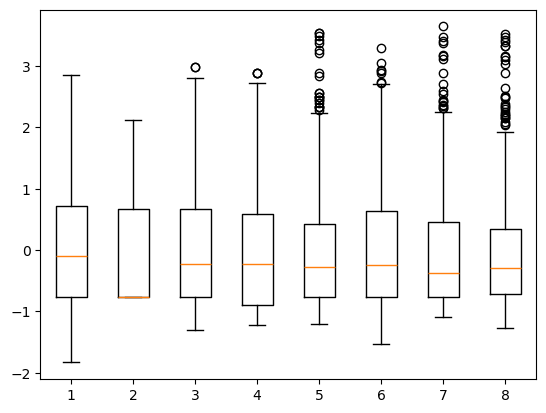

In [13]:
plt.boxplot(X_clean)
plt.show()

In [15]:
X=MinMaxScaler().fit_transform(X_clean,y_clean)
X

array([[0.2       , 0.        , 0.41666667, ..., 0.61904762, 0.32555618,
        0.50278698],
       [0.57142857, 0.        , 0.625     , ..., 0.18681319, 0.203548  ,
        0.2699192 ],
       [0.11428571, 0.5       , 0.08333333, ..., 0.61904762, 0.4280641 ,
        0.38275591],
       ...,
       [0.37142857, 0.        , 0.625     , ..., 0.26373626, 0.1156058 ,
        0.24091181],
       [0.71428571, 0.        , 0.79166667, ..., 0.29304029, 0.55225268,
        0.52371018],
       [0.48571429, 0.        , 0.5       , ..., 0.52380952, 0.71908616,
        0.43573344]])

In [16]:
y

1      0
2      0
4      1
5      0
7      0
      ..
695    1
696    0
697    0
698    0
699    0
Name: default, Length: 552, dtype: int32

In [18]:
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_clean, y_clean)
X_resampled

array([[-0.89457314, -0.76539405,  0.48401386, ...,  1.45270524,
         0.44703034,  1.14418937],
       [ 0.84889694, -0.76539405,  1.37578841, ..., -0.63675748,
        -0.13178661,  0.02744335],
       [-1.29691239,  0.67657699, -0.9428254 , ...,  1.45270524,
         0.93333644,  0.56856564],
       ...,
       [-1.3561079 , -0.76539405, -0.86410221, ..., -0.15292016,
        -0.78647892, -0.55669082],
       [-1.25463071, -0.76539405, -0.93315973, ...,  1.39652928,
        -0.2690003 , -0.14879132],
       [-1.34378923,  0.67657699, -1.03416973, ...,  1.54223462,
        -0.0610621 ,  0.15182305]])

In [19]:
y_resampled

0      0
1      0
2      1
3      0
4      0
      ..
823    1
824    1
825    1
826    1
827    1
Name: default, Length: 828, dtype: int32

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_clean,y_clean, test_size=0.2, random_state=42)   
print('train:',X_train.shape,'test:',X_test.shape)

train: (436, 8) test: (110, 8)


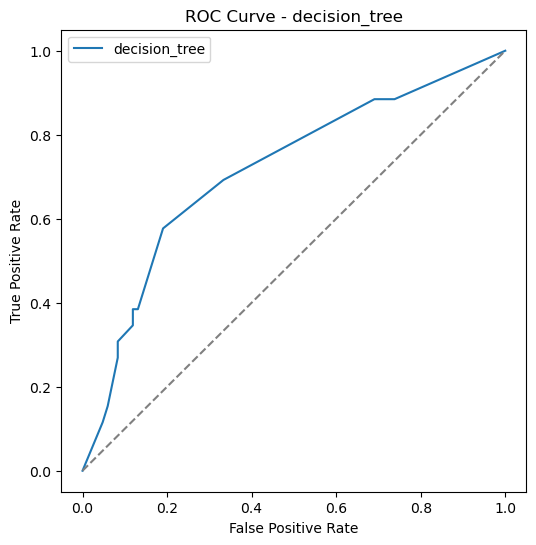

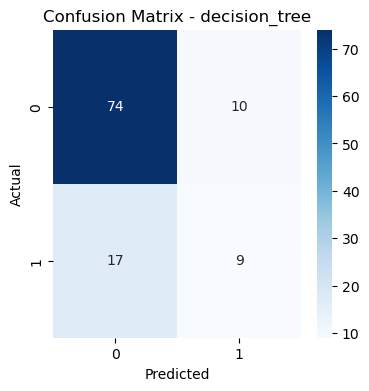

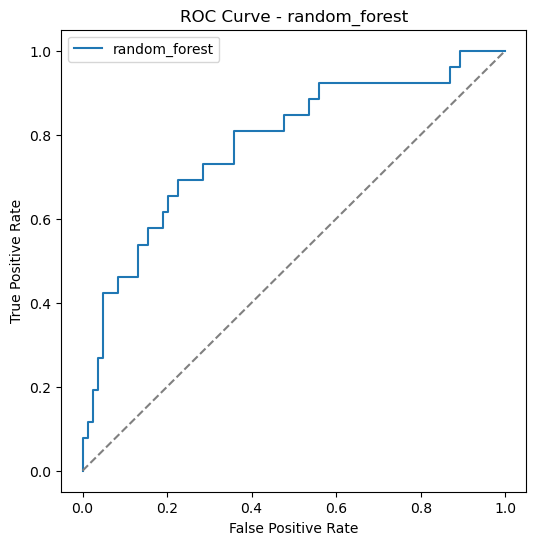

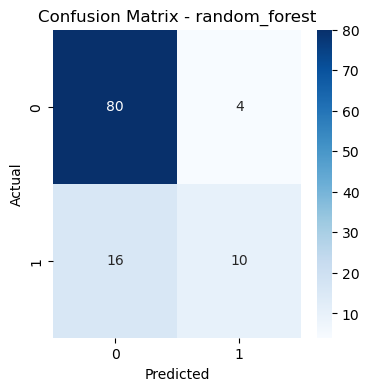

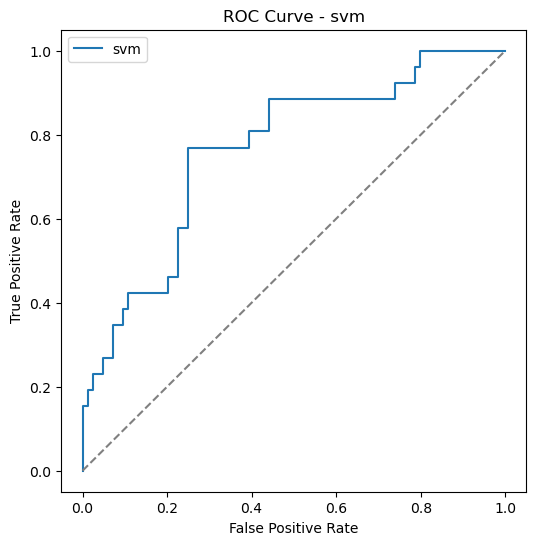

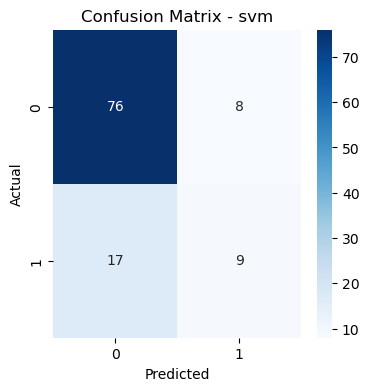

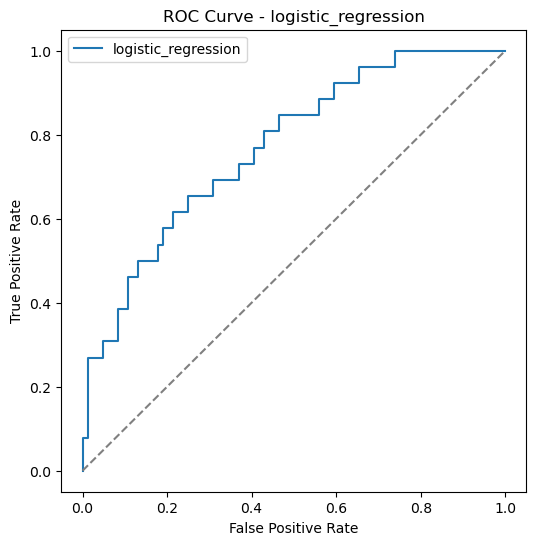

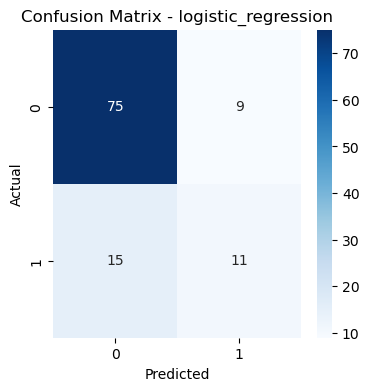

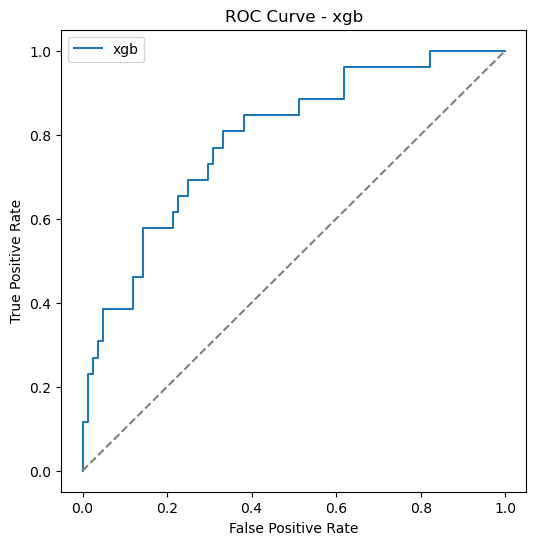

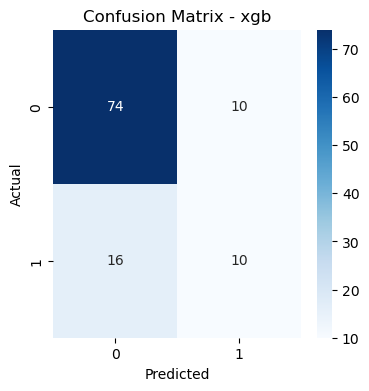

[LightGBM] [Info] Number of positive: 106, number of negative: 330
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.243119 -> initscore=-1.135654
[LightGBM] [Info] Start training from score -1.135654
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


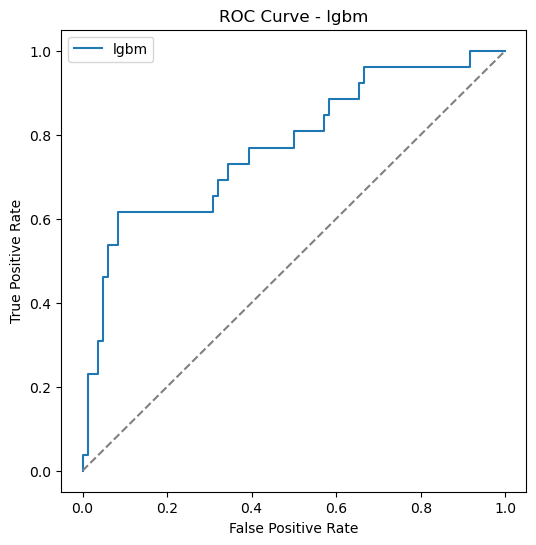

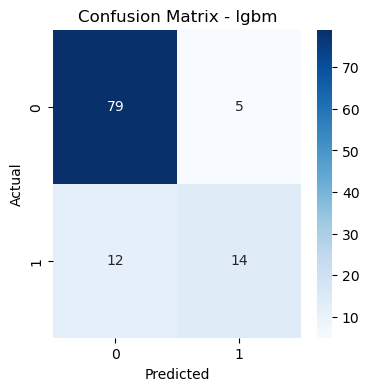

In [45]:
models = {
    'decision_tree': DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, criterion='entropy'),
    'svm': SVC(probability=True),
    'logistic_regression': LogisticRegression(),
    'xgb': XGBClassifier(),
    'lgbm': LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=10,
    random_state=42)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] 

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred)
    })
    roc = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 6))
    plt.plot(roc[0], roc[1], label=name)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.show()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [42]:
cm = classification_report(y_test, y_pred)
print('\n',cm)


               precision    recall  f1-score   support

           0       0.87      0.94      0.90        84
           1       0.74      0.54      0.62        26

    accuracy                           0.85       110
   macro avg       0.80      0.74      0.76       110
weighted avg       0.84      0.85      0.84       110



In [40]:
results_df = pd.DataFrame(results)
results_df.to_csv(r'C:\Pranaya\creditworthiness\model_results.csv', index=False)

In [48]:
import os
import pickle

model_path = r'C:\Pranaya\creditworthiness\model.pkl'

if not os.path.exists(model_path):
    with open(model_path, 'wb') as f:
        pickle.dump(models['lgbm'], f)

with open(model_path, 'rb') as f:
    model = pickle.load(f)
